# Behavioral Signature Profile
This notebook loads 5 stocks with a price > 1500, pre-2021 data (2019-2020), and plots them.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))

# Seed System
SEED = 99 # Changed to test a different batch of stocks
random.seed(SEED)
random.shuffle(files)

def calc_atr_and_adx(df, period=14):
    high = df['High']
    low = df['Low']
    close = df['Close']
    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR_14'] = tr.rolling(period).mean()
    df['ATR_Pct'] = (df['ATR_14'] / close) * 100
    return df

def calc_omega_pr(series, period, lookback=200):
    daily_returns = series.pct_change()
    def get_omega(ret_window):
        gains = ret_window[ret_window > 0].sum()
        losses = abs(ret_window[ret_window < 0].sum())
        if losses == 0: 
            return gains / 0.0001 if gains > 0 else 1.0
        return gains / losses
    rolling_omega = daily_returns.rolling(period).apply(get_omega, raw=False)
    pr = rolling_omega.rolling(lookback).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False)
    return pr

# Find 5 stocks with price > 1500 in 2019-2020
selected_files = []
data_dict = {}

for f in files:
    try:
        df = pd.read_csv(f)
        df['Date'] = pd.to_datetime(df['Date'])
        df = calc_atr_and_adx(df)
        
        # Calculate Indicators on Full History to avoid NaN at start of 2019
        df['EMA_8'] = df['Close'].ewm(span=8, adjust=False).mean()
        df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
        df['EMA_55'] = df['Close'].ewm(span=55, adjust=False).mean()
        df['EMA_144'] = df['Close'].ewm(span=144, adjust=False).mean()
        
        # Behavioral Signature: Stacked EMAs
        df['EMA_Aligned'] = (df['EMA_8'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55']) & (df['EMA_55'] > df['EMA_144'])
        
        df['Omega_5_PR'] = calc_omega_pr(df['Close'], 5)
        df['Omega_13_PR'] = calc_omega_pr(df['Close'], 13)
        df['Omega_21_PR'] = calc_omega_pr(df['Close'], 21)
        df['Omega_34_PR'] = calc_omega_pr(df['Close'], 34)
        
        # Filter 2019-2020
        df = df[(df['Date'] >= '2019-01-01') & (df['Date'] <= '2020-12-31')]
        
        if len(df) > 400: # Ensure enough data
            if df['Close'].mean() > 1500:
                symbol = os.path.basename(f).split('.')[0]
                selected_files.append(symbol)
                data_dict[symbol] = df
                if len(selected_files) == 5:
                    break
    except:
        pass

print(f'Selected Stocks: {selected_files}')

Selected Stocks: ['WHIRLPOOL', 'ASTRAZEN', 'MRF', 'HINDUNILVR', 'BAJAJ-AUTO']


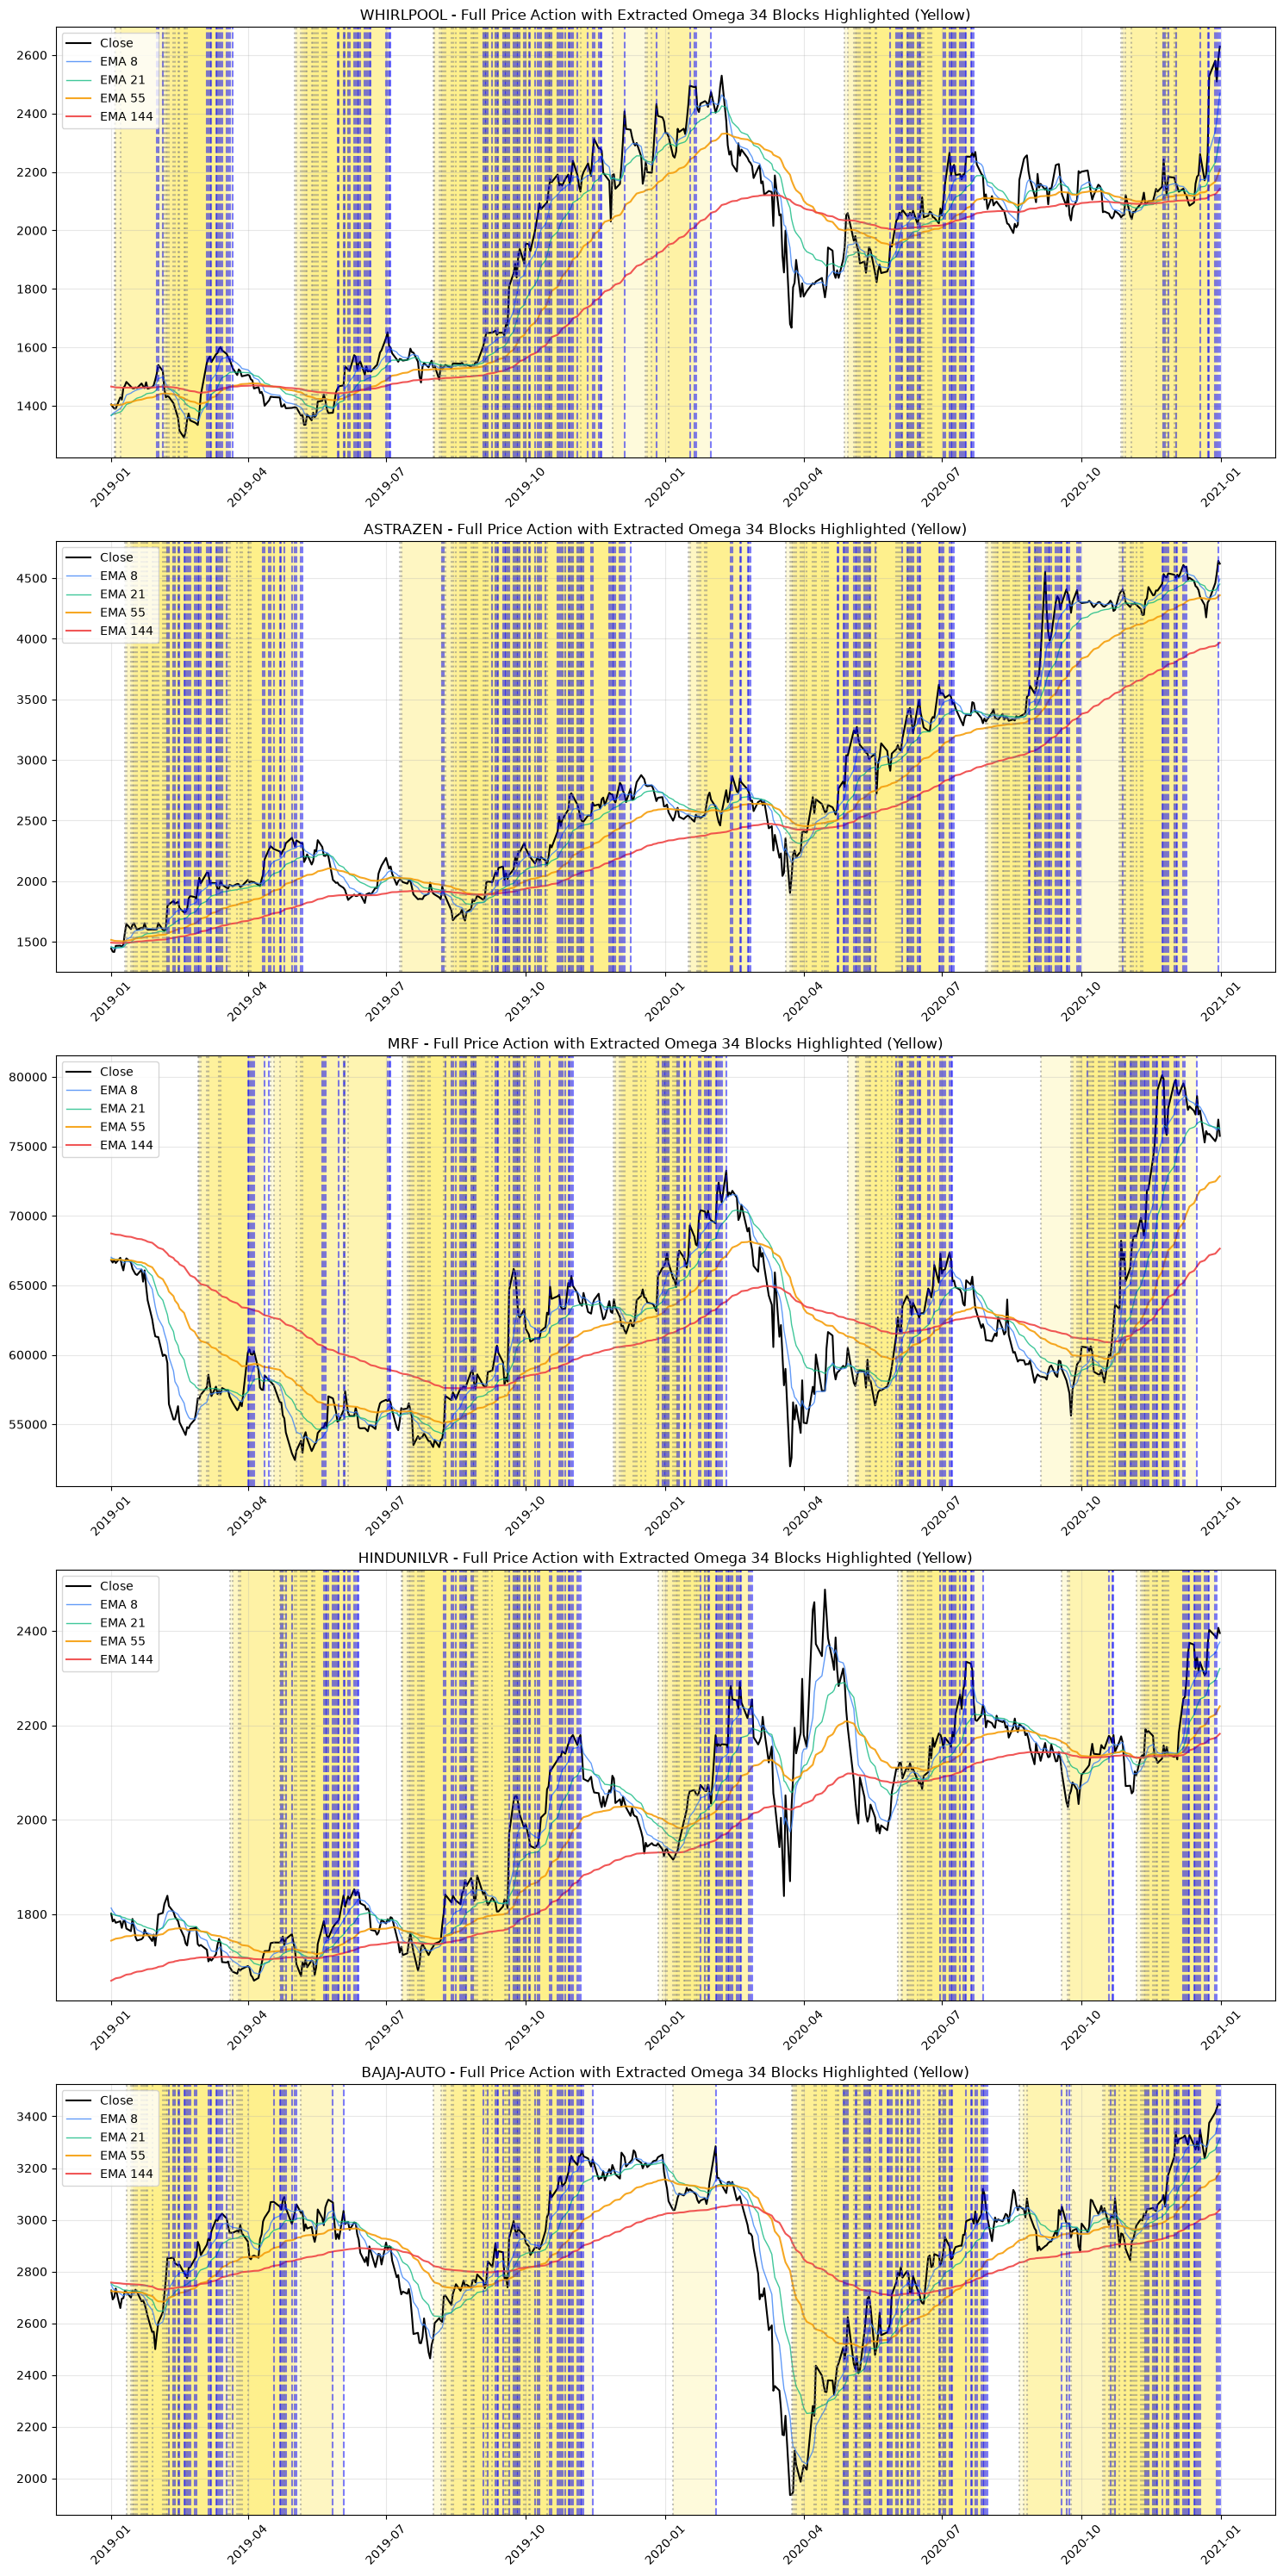

In [2]:
# Plot only Price with extracted 21-Day Blocks marked
fig, axes = plt.subplots(len(selected_files), 1, figsize=(15, 6 * len(selected_files)))
if len(selected_files) == 1: axes = [axes]

for i, symbol in enumerate(selected_files):
    df = data_dict[symbol]
    ax = axes[i]
    
    # --- Price Plot ---
    ax.plot(df['Date'], df['Close'], color='black', linewidth=1.5, label='Close')
    ax.plot(df['Date'], df['EMA_8'], color='#3b82f6', linewidth=1, alpha=0.8, label='EMA 8')
    ax.plot(df['Date'], df['EMA_21'], color='#10b981', linewidth=1, alpha=0.8, label='EMA 21')
    ax.plot(df['Date'], df['EMA_55'], color='#f59e0b', linewidth=1.5, alpha=0.9, label='EMA 55')
    ax.plot(df['Date'], df['EMA_144'], color='#ef4444', linewidth=1.5, alpha=0.9, label='EMA 144')
    
    # Find all the valid blocks for Omega 34 to highlight
    BLOCK_SIZE = 21
    for j in range(BLOCK_SIZE, len(df)):
        if df.iloc[j]['Omega_34_PR'] > 50:
            past_14_start = df.iloc[j - 13]['Close']
            past_14_end = df.iloc[j]['Close']
            past_14_return = ((past_14_end - past_14_start) / past_14_start) * 100
            
            if past_14_return >= 3.0:
                start_date = df['Date'].iloc[j - BLOCK_SIZE + 1]
                end_date = df['Date'].iloc[j]
                # Draw a light yellow shaded box for the valid block
                ax.axvspan(start_date, end_date, color='#fef08a', alpha=0.3, lw=0)
                # Mark the exact start and end with vertical lines
                ax.axvline(start_date, color='gray', linestyle=':', alpha=0.5)
                ax.axvline(end_date, color='blue', linestyle='--', alpha=0.5)

    ax.set_title(f'{symbol} - Full Price Action with Extracted Omega 34 Blocks Highlighted (Yellow)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


,Regime,Total Blocks
0,All Possible 21-Day Blocks,2365
1,Omega 34 > 50 & 14d Ret >= 3%,683
2,Omega 21 > 50 & 14d Ret >= 3%,747


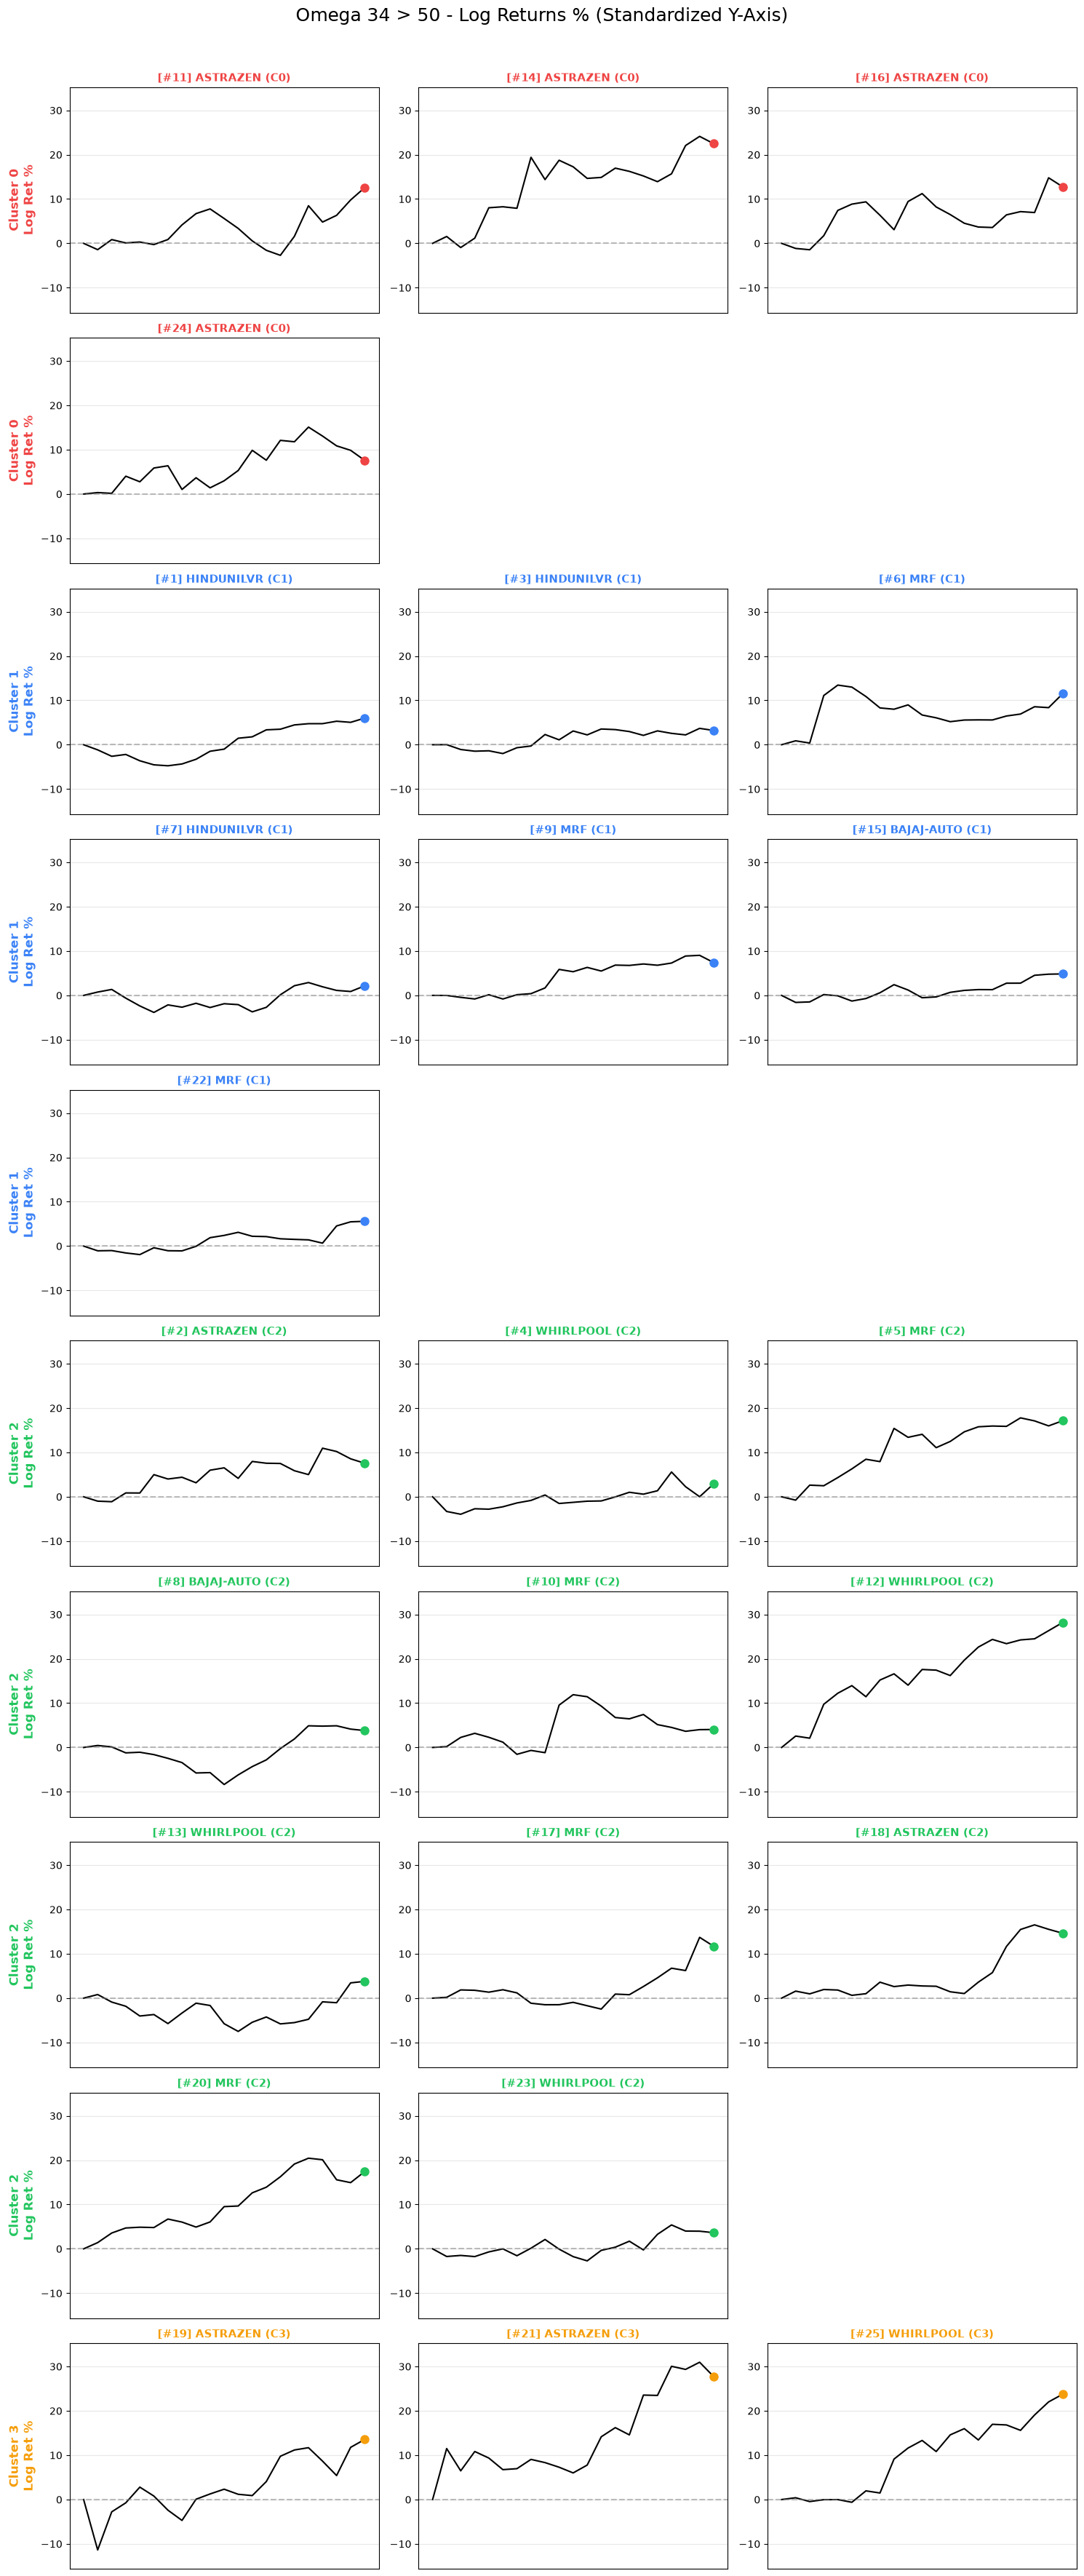

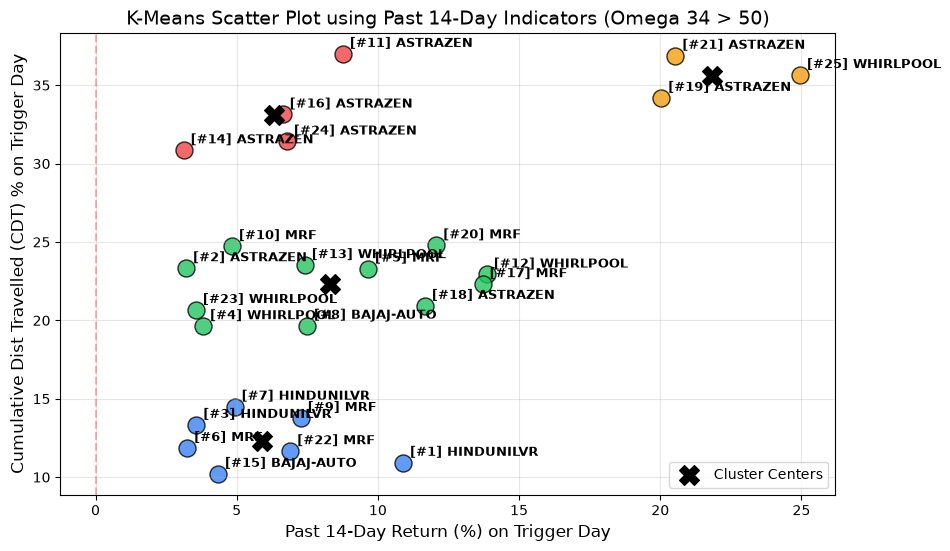

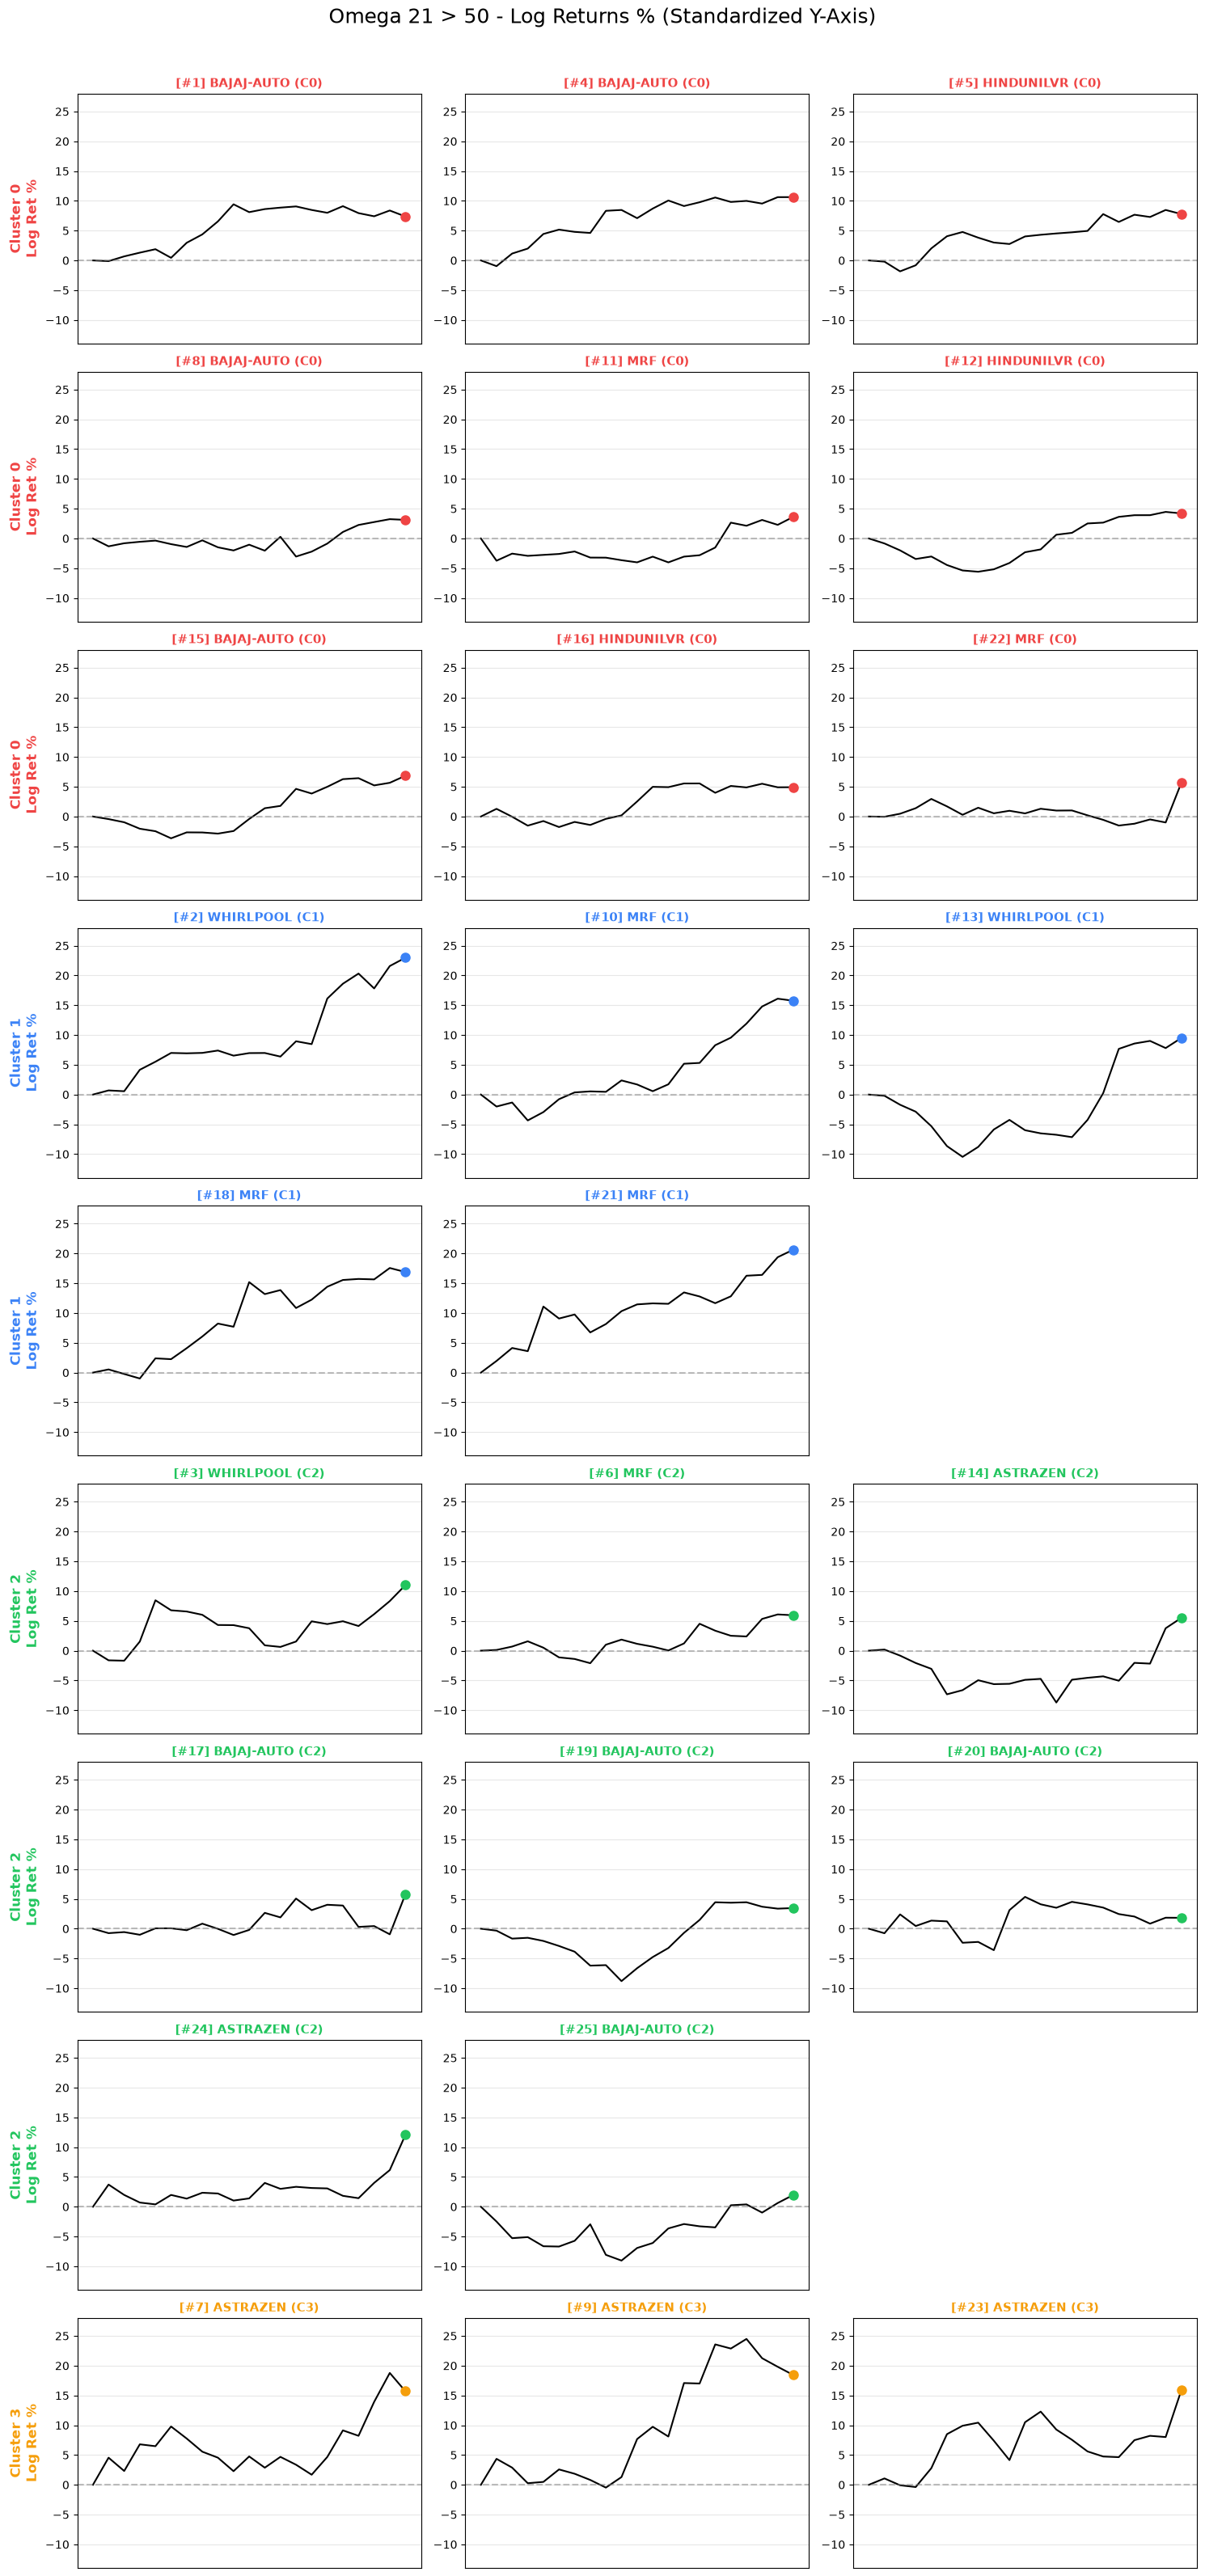

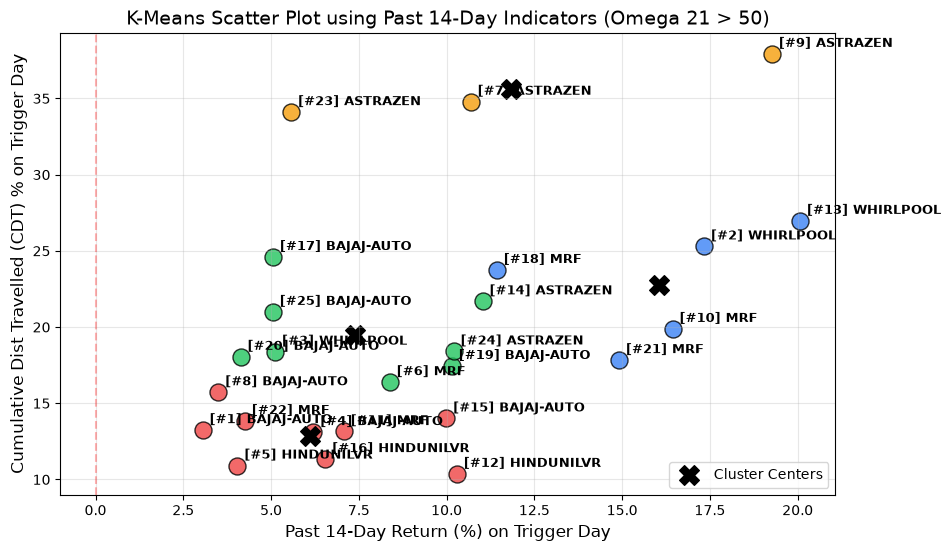

In [3]:
# Cell 3: Extracting and Plotting 21-Day Blocks
BLOCK_SIZE = 21

blocks_34 = []
blocks_21 = []

import numpy as np
import pandas as pd
import math
import random
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from IPython.display import display, HTML

for symbol in selected_files:
    df = data_dict[symbol]
    
    for i in range(BLOCK_SIZE, len(df)):
        if df.iloc[i]['Omega_34_PR'] > 50:
            past_14_start = df.iloc[i - 13]['Close']
            past_14_end = df.iloc[i]['Close']
            past_14_return = ((past_14_end - past_14_start) / past_14_start) * 100
            
            if past_14_return >= 3.0:
                block = df.iloc[i - BLOCK_SIZE + 1 : i + 1].copy()
                block['Symbol'] = symbol
                block['Past_14_Return'] = past_14_return
                
                past_14_close = df['Close'].iloc[i - 13 : i + 1]
                block['CDT_14d'] = past_14_close.pct_change().abs().sum() * 100
                
                first_close = block['Close'].iloc[0]
                block['Log_Return_Pct'] = np.log(block['Close'] / first_close) * 100
                blocks_34.append(block)
            
        if df.iloc[i]['Omega_21_PR'] > 50:
            past_14_start = df.iloc[i - 13]['Close']
            past_14_end = df.iloc[i]['Close']
            past_14_return = ((past_14_end - past_14_start) / past_14_start) * 100
            
            if past_14_return >= 3.0:
                block = df.iloc[i - BLOCK_SIZE + 1 : i + 1].copy()
                block['Symbol'] = symbol
                block['Past_14_Return'] = past_14_return
                
                past_14_close = df['Close'].iloc[i - 13 : i + 1]
                block['CDT_14d'] = past_14_close.pct_change().abs().sum() * 100
                
                first_close = block['Close'].iloc[0]
                block['Log_Return_Pct'] = np.log(block['Close'] / first_close) * 100
                blocks_21.append(block)

total_possible = sum([len(df) - BLOCK_SIZE for df in data_dict.values()])
summary_df = pd.DataFrame({
    "Regime": ["All Possible 21-Day Blocks", "Omega 34 > 50 & 14d Ret >= 3%", "Omega 21 > 50 & 14d Ret >= 3%"],
    "Total Blocks": [total_possible, len(blocks_34), len(blocks_21)]
})
display(HTML("<h3>Block Extraction Summary (CDT 14d Version)</h3>"))
display(summary_df)

def plot_25_samples_clustered(block_list, title):
    if len(block_list) == 0: return
    sample_size = min(25, len(block_list))
    sample_blocks = random.sample(block_list, sample_size)
    
    returns_14d = []
    cdts_14d = []
    labels_text = []
    
    # Calculate global min/max for standardized Y axis
    global_min_y = min([b['Log_Return_Pct'].min() for b in sample_blocks])
    global_max_y = max([b['Log_Return_Pct'].max() for b in sample_blocks])
    pad = (global_max_y - global_min_y) * 0.1
    ylim_min = global_min_y - pad
    ylim_max = global_max_y + pad
    
    for b in sample_blocks:
        ret_14 = b['Past_14_Return'].iloc[0] 
        cdt_14 = b['CDT_14d'].iloc[0]       
        
        returns_14d.append(ret_14)
        cdts_14d.append(cdt_14)
        labels_text.append(b['Symbol'].iloc[0])
        
    X = np.column_stack((returns_14d, cdts_14d))
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
    cluster_labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    
    # Group the blocks by their assigned cluster
    clusters_dict = {0: [], 1: [], 2: [], 3: []}
    for i in range(len(sample_blocks)):
        clusters_dict[cluster_labels[i]].append({
            'block': sample_blocks[i],
            'ret': returns_14d[i],
            'cdt': cdts_14d[i],
            'label': labels_text[i],
            'global_idx': i + 1
        })
        
    total_rows = sum([max(1, math.ceil(len(items)/3)) for items in clusters_dict.values()])
    
    colors = ['#ef4444', '#3b82f6', '#22c55e', '#f59e0b']
    
    fig, axes = plt.subplots(total_rows, 3, figsize=(15, 3.5 * total_rows))
    
    if total_rows == 1:
        axes = np.array([axes])
        
    current_row = 0
    
    for cluster_id in range(4):
        c_color = colors[cluster_id]
        cluster_items = clusters_dict[cluster_id]
        
        if len(cluster_items) == 0:
            for col in range(3):
                axes[current_row, col].axis('off')
            current_row += 1
            continue
            
        col_idx = 0
        for i, item in enumerate(cluster_items):
            if col_idx == 3:
                col_idx = 0
                current_row += 1
                
            ax = axes[current_row, col_idx]
            block = item['block']
            idx = item['global_idx']
            
            days = range(1, BLOCK_SIZE + 1)
            ax.plot(days, block['Log_Return_Pct'], color='black', linewidth=1.5)
            end_val = block['Log_Return_Pct'].iloc[-1]
            ax.plot(days[-1], end_val, marker='o', markersize=8, color=c_color) 
            
            ax.set_title(f"[#{idx}] {item['label']} (C{cluster_id})", fontsize=11, color=c_color, weight='bold')
            ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
            ax.set_ylim(ylim_min, ylim_max)
            ax.set_xticks([])
            ax.grid(True, alpha=0.3)
            
            if col_idx == 0:
                ax.set_ylabel(f"Cluster {cluster_id}\nLog Ret %", fontsize=12, color=c_color, weight='bold')
                
            col_idx += 1
            
        # Turn off remaining axes in this row
        while col_idx < 3:
            axes[current_row, col_idx].axis('off')
            col_idx += 1
            
        current_row += 1
                
    plt.suptitle(f"{title} - Log Returns % (Standardized Y-Axis)", fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # 2) Scatter Plot
    plt.figure(figsize=(10, 6))
    for row in range(4):
        c_color = colors[row]
        cluster_items = clusters_dict[row]
        for item in cluster_items:
            plt.scatter(item['ret'], item['cdt'], color=c_color, s=150, alpha=0.8, edgecolor='black')
            plt.annotate(f"[#{item['global_idx']}] {item['label']}", (item['ret'], item['cdt']), xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold')
            
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Cluster Centers')
    plt.axvline(0, color='red', linestyle='--', alpha=0.3)
    plt.title(f'K-Means Scatter Plot using Past 14-Day Indicators ({title})', fontsize=14)
    plt.xlabel('Past 14-Day Return (%) on Trigger Day', fontsize=12)
    plt.ylabel('Cumulative Dist Travelled (CDT) % on Trigger Day', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_25_samples_clustered(blocks_34, "Omega 34 > 50")
plot_25_samples_clustered(blocks_21, "Omega 21 > 50")
